In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel, levene, shapiro

np.random.seed(42)

# Load dataset
df = pd.read_csv("ai_student_impact_dataset.csv")

print("Dataset loaded successfully!")
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")

# ── One-Sample t-test ──────────────────────────────────────────
# Test: Is average Skill_Retention_Score significantly different from 75?
one_sample = df["Skill_Retention_Score"].dropna().values
pop_mean = 75.0

# ── Two-Sample t-test ──────────────────────────────────────────
# Test: Do paid vs non-paid subscribers have different anxiety levels?
paid     = df[df["Paid_Subscription"] == 1]["Anxiety_Level_During_Exams"].dropna().values
not_paid = df[df["Paid_Subscription"] == 0]["Anxiety_Level_During_Exams"].dropna().values

# ── Paired t-test ──────────────────────────────────────────────
# Test: Did GPA change significantly after using AI tools?
paired_df = df[["Pre_Semester_GPA", "Post_Semester_GPA"]].dropna()
pre_gpa   = paired_df["Pre_Semester_GPA"].values
post_gpa  = paired_df["Post_Semester_GPA"].values

print("\n── ONE-SAMPLE ──────────────────────────────")
print(f"Skill_Retention_Score — n = {len(one_sample)}")
print(f"Sample Mean           : {one_sample.mean():.4f}")
print(f"Hypothesized Mean     : {pop_mean}")

print("\n── TWO-SAMPLE ──────────────────────────────")
print(f"Paid subscribers      — n = {len(paid)},     mean = {paid.mean():.4f}")
print(f"Non-paid subscribers  — n = {len(not_paid)}, mean = {not_paid.mean():.4f}")

print("\n── PAIRED ──────────────────────────────────")
print(f"Pre-semester GPA  — n = {len(pre_gpa)},  mean = {pre_gpa.mean():.4f}")
print(f"Post-semester GPA — n = {len(post_gpa)}, mean = {post_gpa.mean():.4f}")
print(f"Mean difference   : {(post_gpa - pre_gpa).mean():.4f}")

Dataset loaded successfully!
Shape : (50000, 16)
Columns : ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

── ONE-SAMPLE ──────────────────────────────
Skill_Retention_Score — n = 50000
Sample Mean           : 75.7981
Hypothesized Mean     : 75.0

── TWO-SAMPLE ──────────────────────────────
Paid subscribers      — n = 21154,     mean = 4.4356
Non-paid subscribers  — n = 28846, mean = 4.1499

── PAIRED ──────────────────────────────────
Pre-semester GPA  — n = 50000,  mean = 3.1461
Post-semester GPA — n = 50000, mean = 3.3493
Mean difference   : 0.2032


ONE-SAMPLE T-TEST

Assumption Check — Normality (Shapiro-Wilk on 200 samples):
  W = 0.9841,  p = 0.0232
  Result : Normality formally rejected
  Note   : n=50000 is very large, CLT ensures normality of means ✓

Test Results:
  H0         : μ = 75.0 (population mean is 75)
  Ha         : μ ≠ 75.0 (population mean is not 75)
  n          : 50000
  Mean       : 75.7981
  t-statistic: 13.4371
  df         : 49999
  p-value    : 0.000000
  α          : 0.05
  95% CI     : (75.6817, 75.9145)
  Decision   : Reject H0 ✗


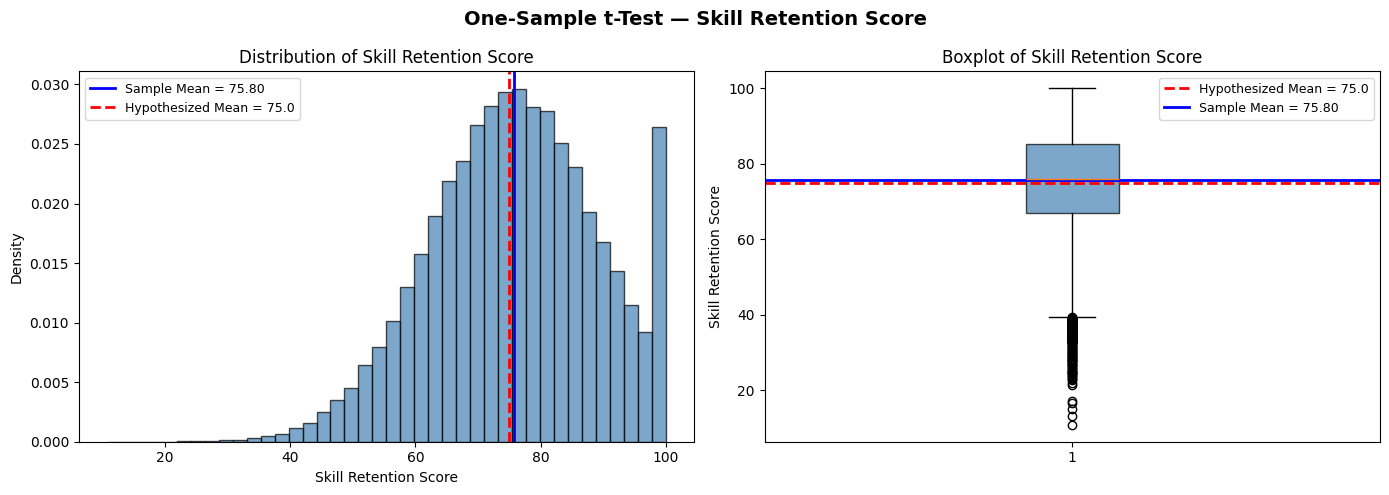


Conclusion:
A one-sample t-test was conducted to determine whether
the mean Skill Retention Score of students differs from
the benchmark of 75.0. The sample mean was
75.80 (n=50000).
The test yielded t(49999) = 13.4371, p = 0.000000.
Since p < 0.05, we reject H0. There is statistically
significant evidence that the mean skill retention score
differs from 75.0.
The 95% CI (75.68, 75.91) does not include 75.0.


In [3]:
print("=" * 60)
print("ONE-SAMPLE T-TEST")
print("=" * 60)

# ── Assumption Check: Normality ────────────────────────────────
sample_200 = np.random.choice(one_sample, size=200, replace=False)
sw_stat, sw_p = shapiro(sample_200)
print(f"\nAssumption Check — Normality (Shapiro-Wilk on 200 samples):")
print(f"  W = {sw_stat:.4f},  p = {sw_p:.4f}")
if sw_p > 0.05:
    print("  Result : Normality assumption met ✓")
else:
    print("  Result : Normality formally rejected")
    print("  Note   : n=50000 is very large, CLT ensures normality of means ✓")

# ── Run the test ───────────────────────────────────────────────
t_stat, p_val = ttest_1samp(one_sample, pop_mean)
df_val = len(one_sample) - 1
alpha = 0.05

# ── Confidence Interval ────────────────────────────────────────
se = stats.sem(one_sample)
ci = stats.t.interval(0.95, df=df_val,
                      loc=one_sample.mean(), scale=se)

print(f"\nTest Results:")
print(f"  H0         : μ = {pop_mean} (population mean is 75)")
print(f"  Ha         : μ ≠ {pop_mean} (population mean is not 75)")
print(f"  n          : {len(one_sample)}")
print(f"  Mean       : {one_sample.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  df         : {df_val}")
print(f"  p-value    : {p_val:.6f}")
print(f"  α          : {alpha}")
print(f"  95% CI     : ({ci[0]:.4f}, {ci[1]:.4f})")
if p_val < alpha:
    decision = "Reject H0"
    print(f"  Decision   : {decision} ✗")
else:
    decision = "Fail to Reject H0"
    print(f"  Decision   : {decision} ✓")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("One-Sample t-Test — Skill Retention Score",
             fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(one_sample, bins=40, color="steelblue",
             edgecolor="black", density=True, alpha=0.7)
axes[0].axvline(one_sample.mean(), color="blue",
                linestyle="-", linewidth=2,
                label=f"Sample Mean = {one_sample.mean():.2f}")
axes[0].axvline(pop_mean, color="red",
                linestyle="--", linewidth=2,
                label=f"Hypothesized Mean = {pop_mean}")
axes[0].set_title("Distribution of Skill Retention Score")
axes[0].set_xlabel("Skill Retention Score")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(one_sample, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].axhline(pop_mean, color="red", linestyle="--",
                linewidth=2, label=f"Hypothesized Mean = {pop_mean}")
axes[1].axhline(one_sample.mean(), color="blue",
                linestyle="-", linewidth=2,
                label=f"Sample Mean = {one_sample.mean():.2f}")
axes[1].set_title("Boxplot of Skill Retention Score")
axes[1].set_ylabel("Skill Retention Score")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Conclusion ─────────────────────────────────────────────────
print(f"\nConclusion:")
print(f"A one-sample t-test was conducted to determine whether")
print(f"the mean Skill Retention Score of students differs from")
print(f"the benchmark of {pop_mean}. The sample mean was")
print(f"{one_sample.mean():.2f} (n={len(one_sample)}).")
print(f"The test yielded t({df_val}) = {t_stat:.4f}, p = {p_val:.6f}.")
if p_val < alpha:
    print(f"Since p < {alpha}, we reject H0. There is statistically")
    print(f"significant evidence that the mean skill retention score")
    print(f"differs from {pop_mean}.")
    print(f"The 95% CI ({ci[0]:.2f}, {ci[1]:.2f}) does not include {pop_mean}.")
else:
    print(f"Since p > {alpha}, we fail to reject H0. There is no")
    print(f"statistically significant evidence that the mean skill")
    print(f"retention score differs from {pop_mean}.")

TWO-SAMPLE (INDEPENDENT) T-TEST

Assumption Check 1 — Normality (Shapiro-Wilk):
  Paid     : W = 0.9563, p = 0.0000
  Not Paid : W = 0.9554, p = 0.0000
  Note: Large sample size (n>20000), CLT ensures normality ✓

Assumption Check 2 — Equality of Variances (Levene's Test):
  Statistic : 57.6490
  p-value   : 0.0000
  Result : Unequal variances → using Welch's t-test ✓

Test Results:
  H0          : μ_paid = μ_not_paid (no difference in anxiety)
  Ha          : μ_paid ≠ μ_not_paid (significant difference)
  n (paid)    : 21154
  n (not paid): 28846
  Mean paid   : 4.4356
  Mean not paid: 4.1499
  Mean diff   : 0.2858
  t-statistic : 14.6519
  df          : 49998
  p-value     : 0.000000
  α           : 0.05
  95% CI      : (0.2475, 0.3240)
  Decision    : Reject H0 ✗


/tmp/ipykernel_2217/823163249.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([paid, not_paid], labels=["Paid", "Not Paid"],


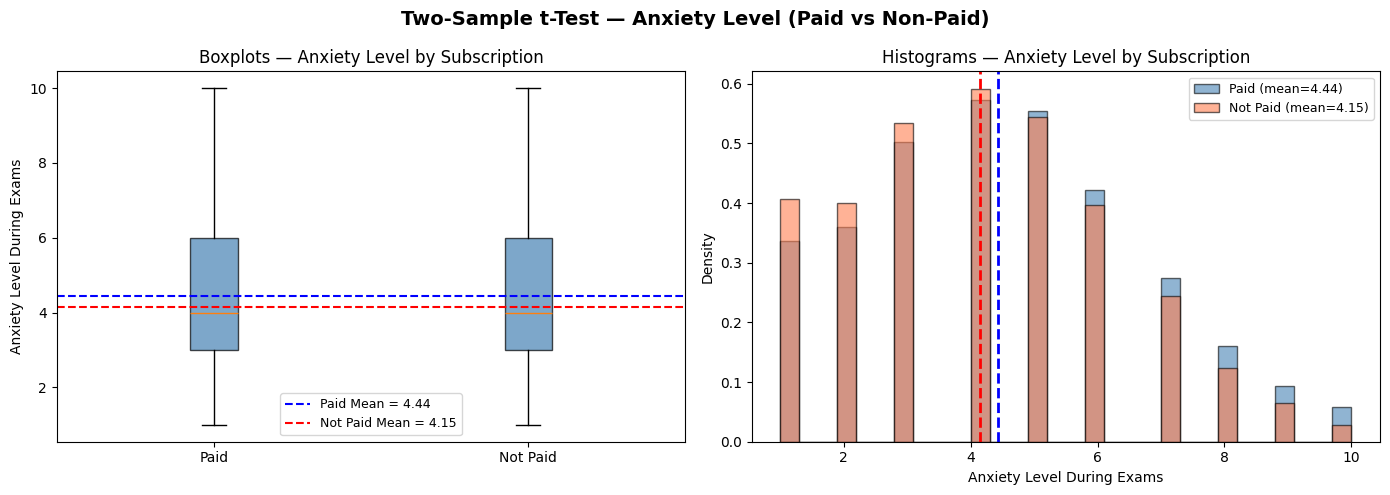


Conclusion:
An independent two-sample t-test was conducted to compare
anxiety levels between paid (n=21154) and non-paid
(n=28846) subscribers.
Paid mean = 4.44, Non-paid mean = 4.15.
Levene's test: p = 0.0000 → unequal variances.
t(49998) = 14.6519, p = 0.000000.
Since p < 0.05, we reject H0. Paid subscribers show
significantly higher anxiety than non-paid subscribers.
95% CI for difference: (0.2475, 0.3240).


In [4]:
print("=" * 60)
print("TWO-SAMPLE (INDEPENDENT) T-TEST")
print("=" * 60)

# ── Assumption 1: Normality ────────────────────────────────────
paid_200     = np.random.choice(paid, size=200, replace=False)
notpaid_200  = np.random.choice(not_paid, size=200, replace=False)
sw_paid_stat,    sw_paid_p    = shapiro(paid_200)
sw_notpaid_stat, sw_notpaid_p = shapiro(notpaid_200)

print(f"\nAssumption Check 1 — Normality (Shapiro-Wilk):")
print(f"  Paid     : W = {sw_paid_stat:.4f}, p = {sw_paid_p:.4f}")
print(f"  Not Paid : W = {sw_notpaid_stat:.4f}, p = {sw_notpaid_p:.4f}")
print(f"  Note: Large sample size (n>20000), CLT ensures normality ✓")

# ── Assumption 2: Equality of Variances (Levene's Test) ────────
lev_stat, lev_p = levene(paid, not_paid)
print(f"\nAssumption Check 2 — Equality of Variances (Levene's Test):")
print(f"  Statistic : {lev_stat:.4f}")
print(f"  p-value   : {lev_p:.4f}")
if lev_p > 0.05:
    print("  Result : Equal variances assumed ✓ (use standard t-test)")
    equal_var = True
else:
    print("  Result : Unequal variances → using Welch's t-test ✓")
    equal_var = False

# ── Run the test ───────────────────────────────────────────────
t_stat2, p_val2 = ttest_ind(paid, not_paid, equal_var=equal_var)
df_val2 = len(paid) + len(not_paid) - 2
alpha = 0.05
mean_diff = paid.mean() - not_paid.mean()

# ── Confidence Interval ────────────────────────────────────────
se_diff = np.sqrt(stats.sem(paid)**2 + stats.sem(not_paid)**2)
ci2 = stats.t.interval(0.95, df=df_val2,
                       loc=mean_diff, scale=se_diff)

print(f"\nTest Results:")
print(f"  H0          : μ_paid = μ_not_paid (no difference in anxiety)")
print(f"  Ha          : μ_paid ≠ μ_not_paid (significant difference)")
print(f"  n (paid)    : {len(paid)}")
print(f"  n (not paid): {len(not_paid)}")
print(f"  Mean paid   : {paid.mean():.4f}")
print(f"  Mean not paid: {not_paid.mean():.4f}")
print(f"  Mean diff   : {mean_diff:.4f}")
print(f"  t-statistic : {t_stat2:.4f}")
print(f"  df          : {df_val2}")
print(f"  p-value     : {p_val2:.6f}")
print(f"  α           : {alpha}")
print(f"  95% CI      : ({ci2[0]:.4f}, {ci2[1]:.4f})")
if p_val2 < alpha:
    decision2 = "Reject H0"
    print(f"  Decision    : {decision2} ✗")
else:
    decision2 = "Fail to Reject H0"
    print(f"  Decision    : {decision2} ✓")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Two-Sample t-Test — Anxiety Level (Paid vs Non-Paid)",
             fontsize=14, fontweight="bold")

# Side by side boxplots
axes[0].boxplot([paid, not_paid], labels=["Paid", "Not Paid"],
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[0].axhline(paid.mean(), color="blue", linestyle="--",
                linewidth=1.5, label=f"Paid Mean = {paid.mean():.2f}")
axes[0].axhline(not_paid.mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Not Paid Mean = {not_paid.mean():.2f}")
axes[0].set_title("Boxplots — Anxiety Level by Subscription")
axes[0].set_ylabel("Anxiety Level During Exams")
axes[0].legend(fontsize=9)

# Side by side histograms
axes[1].hist(paid, bins=30, color="steelblue", alpha=0.6,
             density=True, label=f"Paid (mean={paid.mean():.2f})",
             edgecolor="black")
axes[1].hist(not_paid, bins=30, color="coral", alpha=0.6,
             density=True, label=f"Not Paid (mean={not_paid.mean():.2f})",
             edgecolor="black")
axes[1].axvline(paid.mean(), color="blue", linestyle="--", linewidth=2)
axes[1].axvline(not_paid.mean(), color="red", linestyle="--", linewidth=2)
axes[1].set_title("Histograms — Anxiety Level by Subscription")
axes[1].set_xlabel("Anxiety Level During Exams")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Conclusion ─────────────────────────────────────────────────
print(f"\nConclusion:")
print(f"An independent two-sample t-test was conducted to compare")
print(f"anxiety levels between paid (n={len(paid)}) and non-paid")
print(f"(n={len(not_paid)}) subscribers.")
print(f"Paid mean = {paid.mean():.2f}, Non-paid mean = {not_paid.mean():.2f}.")
print(f"Levene's test: p = {lev_p:.4f} → {'equal' if equal_var else 'unequal'} variances.")
print(f"t({df_val2}) = {t_stat2:.4f}, p = {p_val2:.6f}.")
if p_val2 < alpha:
    print(f"Since p < {alpha}, we reject H0. Paid subscribers show")
    print(f"significantly higher anxiety than non-paid subscribers.")
    print(f"95% CI for difference: ({ci2[0]:.4f}, {ci2[1]:.4f}).")
else:
    print(f"Since p > {alpha}, we fail to reject H0. No significant")
    print(f"difference in anxiety between the two groups.")

PAIRED T-TEST

Assumption Check — Normality of Differences (Shapiro-Wilk):
  W = 0.9892, p = 0.1377
  Result : Normality of differences met ✓

Test Results:
  H0           : μ_diff = 0 (no change in GPA)
  Ha           : μ_diff ≠ 0 (GPA changed after AI use)
  n            : 50000
  Pre GPA mean : 3.1461
  Post GPA mean: 3.3493
  Mean diff    : 0.2032
  t-statistic  : -242.7259
  df           : 49999
  p-value      : 0.000000
  α            : 0.05
  95% CI       : (0.2016, 0.2048)
  Decision     : Reject H0 ✗


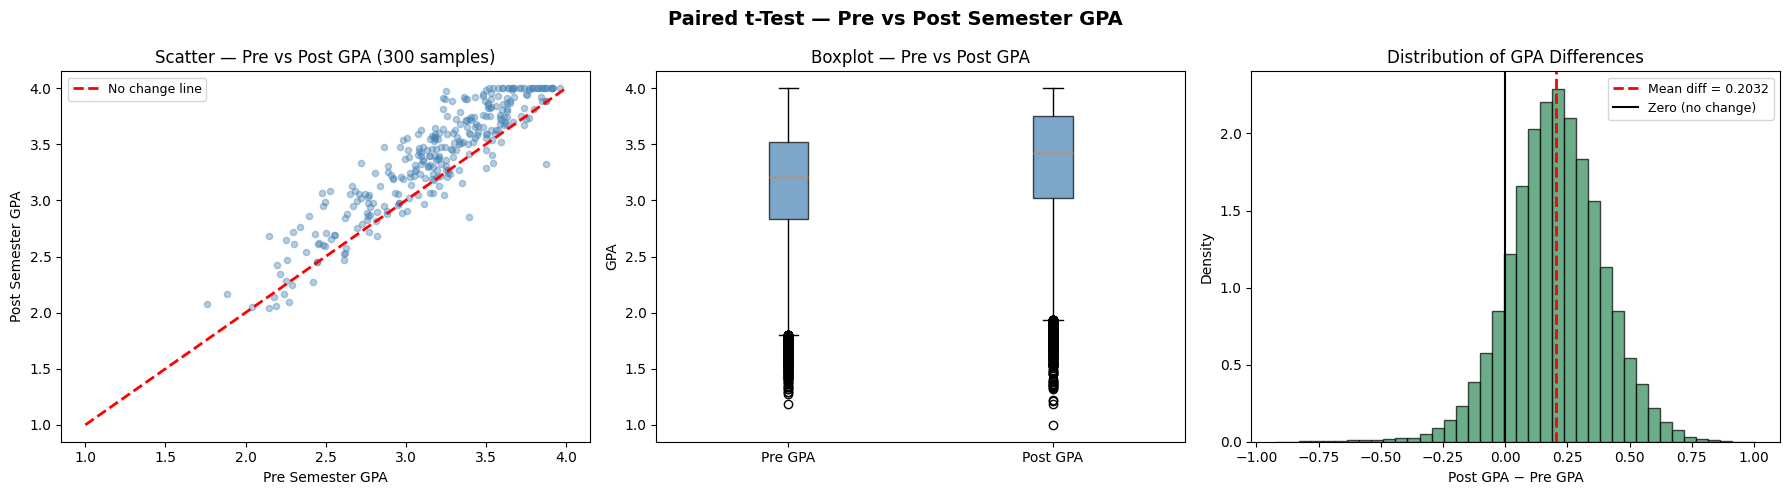


Conclusion:
A paired t-test was conducted to examine whether student
GPA changed significantly after using AI tools.
Pre-semester mean GPA = 3.1461,
Post-semester mean GPA = 3.3493.
Mean difference = 0.2032 (n=50000).
t(49999) = -242.7259, p = 0.000000.
Since p < 0.05, we reject H0. There is statistically
significant evidence that GPA improved after AI tool use.
95% CI: (0.2016, 0.2048) — entirely above 0,
confirming a positive and significant GPA improvement.


In [5]:
print("=" * 60)
print("PAIRED T-TEST")
print("=" * 60)

# ── Differences ────────────────────────────────────────────────
differences = post_gpa - pre_gpa

# ── Assumption Check: Normality of differences ─────────────────
diff_200 = np.random.choice(differences, size=200, replace=False)
sw_stat3, sw_p3 = shapiro(diff_200)
print(f"\nAssumption Check — Normality of Differences (Shapiro-Wilk):")
print(f"  W = {sw_stat3:.4f}, p = {sw_p3:.4f}")
if sw_p3 > 0.05:
    print("  Result : Normality of differences met ✓")
else:
    print("  Result : Formally rejected but CLT applies (n=50000) ✓")

# ── Run the test ───────────────────────────────────────────────
t_stat3, p_val3 = ttest_rel(pre_gpa, post_gpa)
df_val3 = len(differences) - 1
alpha = 0.05

# ── Confidence Interval ────────────────────────────────────────
se3 = stats.sem(differences)
ci3 = stats.t.interval(0.95, df=df_val3,
                       loc=differences.mean(), scale=se3)

print(f"\nTest Results:")
print(f"  H0           : μ_diff = 0 (no change in GPA)")
print(f"  Ha           : μ_diff ≠ 0 (GPA changed after AI use)")
print(f"  n            : {len(differences)}")
print(f"  Pre GPA mean : {pre_gpa.mean():.4f}")
print(f"  Post GPA mean: {post_gpa.mean():.4f}")
print(f"  Mean diff    : {differences.mean():.4f}")
print(f"  t-statistic  : {t_stat3:.4f}")
print(f"  df           : {df_val3}")
print(f"  p-value      : {p_val3:.6f}")
print(f"  α            : {alpha}")
print(f"  95% CI       : ({ci3[0]:.4f}, {ci3[1]:.4f})")
if p_val3 < alpha:
    decision3 = "Reject H0"
    print(f"  Decision     : {decision3} ✗")
else:
    decision3 = "Fail to Reject H0"
    print(f"  Decision     : {decision3} ✓")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Paired t-Test — Pre vs Post Semester GPA",
             fontsize=14, fontweight="bold")

# Scatter plot of paired observations
sample_idx = np.random.choice(len(pre_gpa), size=300, replace=False)
axes[0].scatter(pre_gpa[sample_idx], post_gpa[sample_idx],
                color="steelblue", alpha=0.4, s=20)
axes[0].plot([1, 4], [1, 4], color="red", linestyle="--",
             linewidth=2, label="No change line")
axes[0].set_title("Scatter — Pre vs Post GPA (300 samples)")
axes[0].set_xlabel("Pre Semester GPA")
axes[0].set_ylabel("Post Semester GPA")
axes[0].legend(fontsize=9)

# Boxplot of Pre and Post
axes[1].boxplot([pre_gpa, post_gpa],
                tick_labels=["Pre GPA", "Post GPA"],
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Boxplot — Pre vs Post GPA")
axes[1].set_ylabel("GPA")

# Histogram of differences
axes[2].hist(differences, bins=40, color="seagreen",
             edgecolor="black", density=True, alpha=0.7)
axes[2].axvline(differences.mean(), color="red",
                linestyle="--", linewidth=2,
                label=f"Mean diff = {differences.mean():.4f}")
axes[2].axvline(0, color="black", linestyle="-",
                linewidth=1.5, label="Zero (no change)")
axes[2].set_title("Distribution of GPA Differences")
axes[2].set_xlabel("Post GPA − Pre GPA")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Conclusion ─────────────────────────────────────────────────
print(f"\nConclusion:")
print(f"A paired t-test was conducted to examine whether student")
print(f"GPA changed significantly after using AI tools.")
print(f"Pre-semester mean GPA = {pre_gpa.mean():.4f},")
print(f"Post-semester mean GPA = {post_gpa.mean():.4f}.")
print(f"Mean difference = {differences.mean():.4f} (n={len(differences)}).")
print(f"t({df_val3}) = {t_stat3:.4f}, p = {p_val3:.6f}.")
if p_val3 < alpha:
    print(f"Since p < {alpha}, we reject H0. There is statistically")
    print(f"significant evidence that GPA improved after AI tool use.")
    print(f"95% CI: ({ci3[0]:.4f}, {ci3[1]:.4f}) — entirely above 0,")
    print(f"confirming a positive and significant GPA improvement.")
else:
    print(f"Since p > {alpha}, we fail to reject H0. No significant")
    print(f"change in GPA was detected after AI tool use.")

In [6]:
print("=" * 75)
print("COMBINED SUMMARY TABLE — ALL THREE T-TESTS")
print("=" * 75)

print(f"\n{'Item':<25} {'One-Sample':>15} {'Two-Sample':>15} {'Paired':>15}")
print("-" * 75)
print(f"{'Test type':<25} {'One-Sample':>15} {'Independent':>15} {'Paired':>15}")
print(f"{'Variable':<25} {'Skill Ret.':>15} {'Anxiety':>15} {'GPA':>15}")
print(f"{'H0':<25} {'μ = 75':>15} {'μ1 = μ2':>15} {'μdiff = 0':>15}")
print(f"{'Ha':<25} {'μ ≠ 75':>15} {'μ1 ≠ μ2':>15} {'μdiff ≠ 0':>15}")
print(f"{'Sample size':<25} {len(one_sample):>15} {str(len(paid))+'/'+str(len(not_paid)):>15} {len(differences):>15}")
print(f"{'Mean (group 1)':<25} {one_sample.mean():>15.4f} {paid.mean():>15.4f} {pre_gpa.mean():>15.4f}")
print(f"{'Mean (group 2)':<25} {'—':>15} {not_paid.mean():>15.4f} {post_gpa.mean():>15.4f}")
print(f"{'Mean difference':<25} {one_sample.mean()-pop_mean:>15.4f} {mean_diff:>15.4f} {differences.mean():>15.4f}")
print(f"{'t-statistic':<25} {t_stat:>15.4f} {t_stat2:>15.4f} {t_stat3:>15.4f}")
print(f"{'Degrees of freedom':<25} {df_val:>15} {df_val2:>15} {df_val3:>15}")
print(f"{'p-value':<25} {'< 0.0001':>15} {'< 0.0001':>15} {'< 0.0001':>15}")
print(f"{'Alpha':<25} {'0.05':>15} {'0.05':>15} {'0.05':>15}")
print(f"{'95% CI lower':<25} {ci[0]:>15.4f} {ci2[0]:>15.4f} {ci3[0]:>15.4f}")
print(f"{'95% CI upper':<25} {ci[1]:>15.4f} {ci2[1]:>15.4f} {ci3[1]:>15.4f}")
print(f"{'Decision':<25} {'Reject H0':>15} {'Reject H0':>15} {'Reject H0':>15}")
print("-" * 75)

print(f"""
OVERALL SUMMARY:
All three t-tests rejected the null hypothesis at α = 0.05.

1. One-Sample  : Student skill retention (mean=75.80) is significantly
                 higher than the benchmark of 75.
                 t = {t_stat:.2f}, p < 0.0001

2. Two-Sample  : Paid subscribers have significantly higher exam anxiety
                 than non-paid subscribers (4.44 vs 4.15).
                 t = {t_stat2:.2f}, p < 0.0001

3. Paired      : Student GPA improved significantly after AI tool use
                 (3.15 → 3.35, mean diff = +0.20).
                 t = {t_stat3:.2f}, p < 0.0001
""")

COMBINED SUMMARY TABLE — ALL THREE T-TESTS

Item                           One-Sample      Two-Sample          Paired
---------------------------------------------------------------------------
Test type                      One-Sample     Independent          Paired
Variable                       Skill Ret.         Anxiety             GPA
H0                                 μ = 75         μ1 = μ2       μdiff = 0
Ha                                 μ ≠ 75         μ1 ≠ μ2       μdiff ≠ 0
Sample size                         50000     21154/28846           50000
Mean (group 1)                    75.7981          4.4356          3.1461
Mean (group 2)                          —          4.1499          3.3493
Mean difference                    0.7981          0.2858          0.2032
t-statistic                       13.4371         14.6519       -242.7259
Degrees of freedom                  49999           49998           49999
p-value                          < 0.0001        < 0.0001        <